# Titanic Survival Prediction — EDA

**Objective**: Understand the factors that influenced passenger survival on the Titanic. This will act as a foundation for feature engineering and modeling in subsequent steps.

**Scope**: EDA only. Feature engineering and modeling are in separate notebooks.

## 1. Data Loading & First Look

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [9]:
df = pd.read_csv('../data/train.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
df_test = pd.read_csv('../data/test.csv')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## 2. Data Quality Assessment

### Missing Values

In [16]:
missing = df.isnull().sum()
missing

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
missing = df_test.isnull().sum()
missing

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [18]:

missing_pct = (missing / len(df) * 100).round(1)
missing_pct

PassengerId     0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age             9.7
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.1
Cabin          36.7
Embarked        0.0
dtype: float64

In [19]:
missing_summary = pd.DataFrame({'Count': missing, '%': missing_pct})
missing_summary[missing_summary['Count'] > 0].sort_values('%', ascending=False)

,Count,%
Cabin,327,36.7
Age,86,9.7
Fare,1,0.1


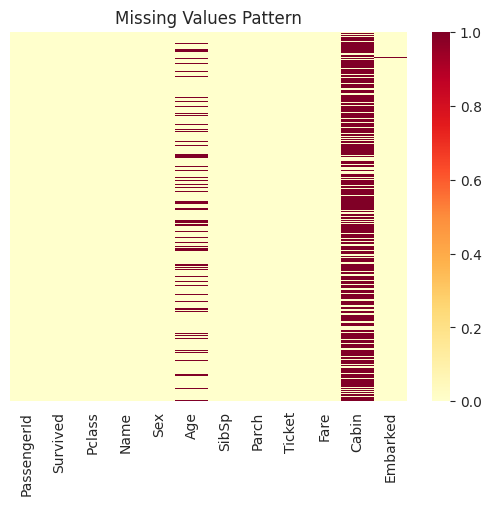

In [20]:
# Visualize missing data pattern
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd')
plt.title("Missing Values Pattern")
plt.show()

**Observations:**
- **Cabin**: 77% missing —> too sparse to use directly, but we can extract `HasCabin` as a binary feature
- **Age**: 20% missing —> significant. Need to check if missingness is random
- **Embarked**: 0.2% missing —> just 2 rows, impute with mode


**Note:**
 - Fare has no missing values in the training set but has 1 missing value in the test set. We will impute it using the median fare for the corresponding Pclass during feature engineering.


In [21]:
# Is Age missing at random?
print("Count of missing Age values: ", df['Age'].isnull().sum())
print("Age missing rate by Pclass:")
print(df.groupby('Pclass')['Age'].apply(lambda x: x.isnull().mean() * 100).round(1))
print()
print("Age missing rate by Sex:")
print(df.groupby('Sex')['Age'].apply(lambda x: x.isnull().mean() * 100).round(1))

Count of missing Age values:  177
Age missing rate by Pclass:
Pclass
1    13.9
2     6.0
3    27.7
Name: Age, dtype: float64

Age missing rate by Sex:
Sex
female    16.9
male      21.5
Name: Age, dtype: float64


Age missingness is **not completely random** — 3rd class has a higher missing rate. For imputation, grouping by Pclass + Sex is better than global median.

### Duplicates

In [22]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


### Outliers

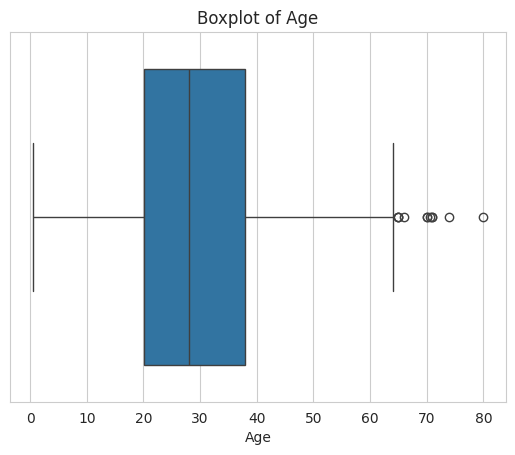

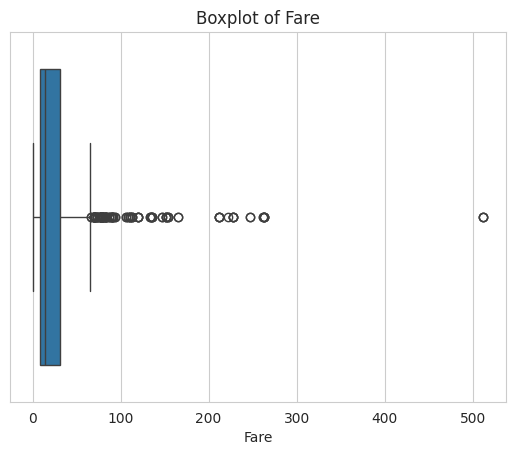

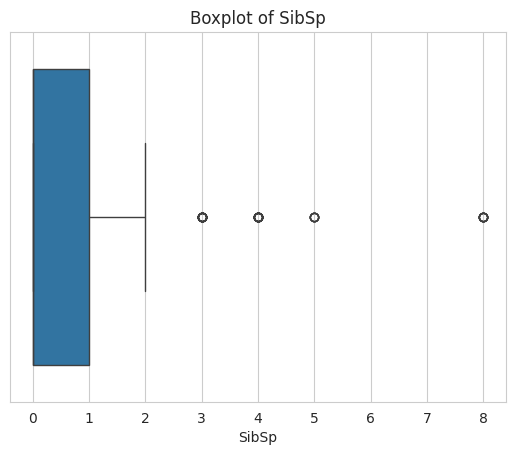

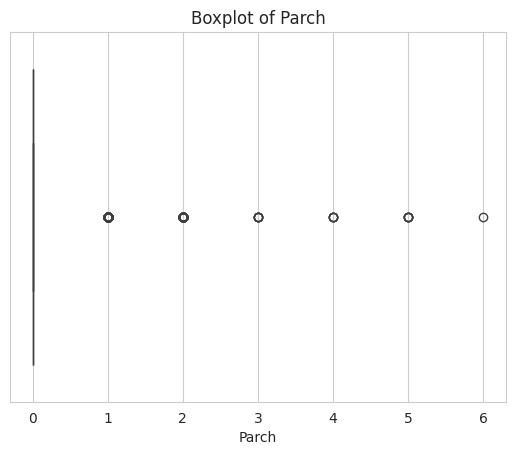

In [23]:
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Observations:**
- **Fare** has extreme outliers (max ~$512, likely group tickets). Log-transform for modeling.
- **SibSp/Parch**: A few large families — real data, not errors.
- **Age**: No extreme outliers.

## 3. Univariate Analysis

### Target Variable — Survived

Survival rate: 38.4%


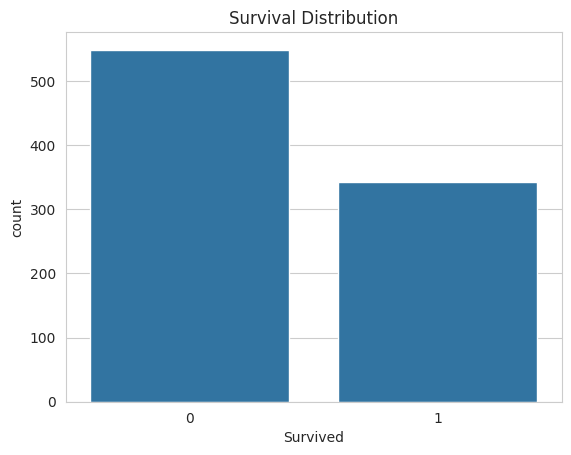

In [24]:
print(f"Survival rate: {df['Survived'].mean()*100:.1f}%")
sns.countplot(x='Survived', data=df)
plt.title("Survival Distribution")
plt.show()

38% survived — moderately imbalanced.

### Categorical Features


Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


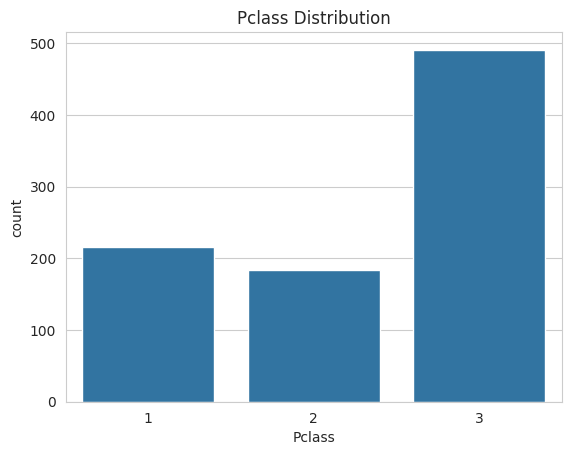


Sex:
Sex
male      577
female    314
Name: count, dtype: int64


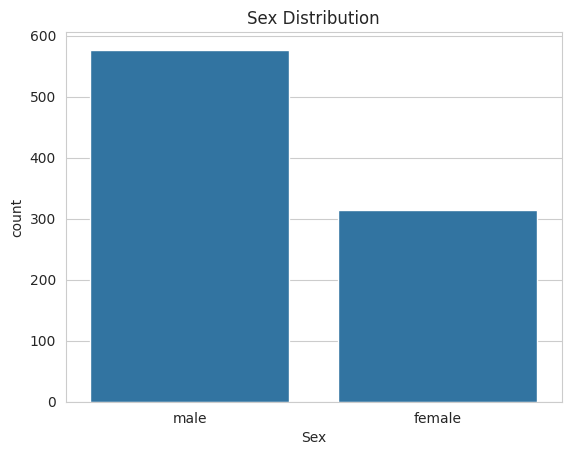


Embarked:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


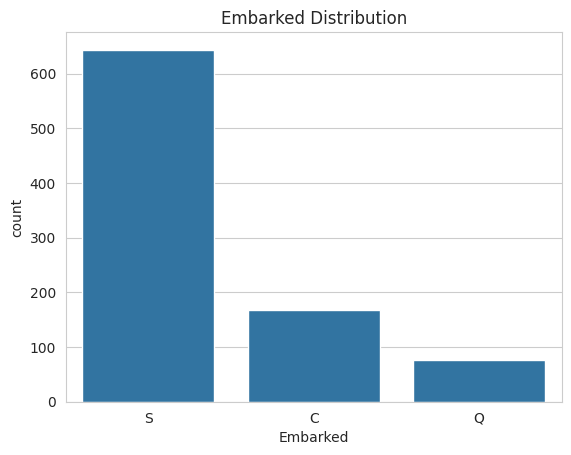

In [25]:
for col in ['Pclass', 'Sex', 'Embarked']:
    print(f"\n{col}:")
    print(df[col].value_counts())
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.show()

**Observations:**
- **Pclass**: Majority 3rd class (55%)
- **Sex**: 65% male, 35% female
- **Embarked**: Southampton dominates (72%)

### Numerical Features

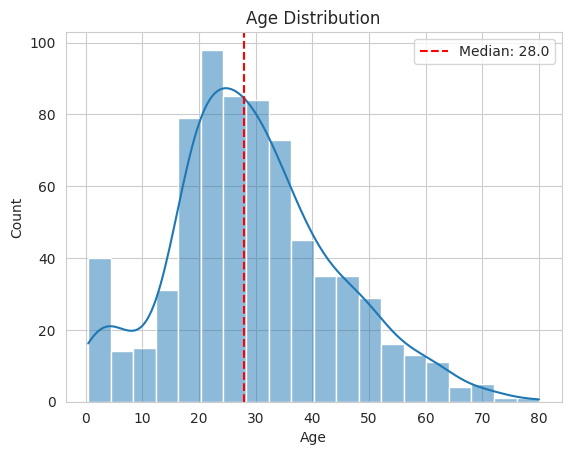

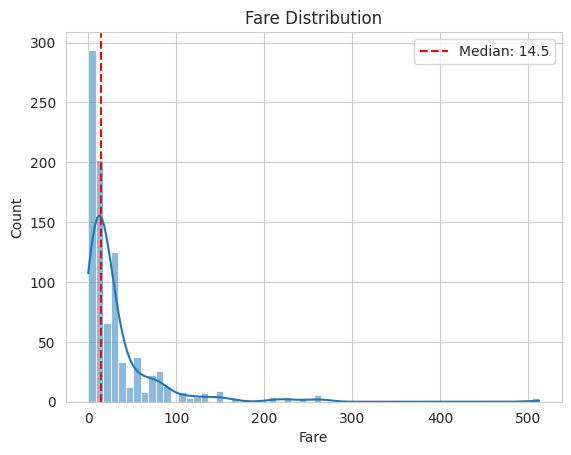

In [26]:
for col in ['Age', 'Fare']:
    sns.histplot(df[col].dropna(), kde=True)
    plt.axvline(df[col].median(), color='red', linestyle='--', label=f'Median: {df[col].median():.1f}')
    plt.title(f"{col} Distribution")
    plt.legend()
    plt.show()

- **Age**: Roughly normal, centered ~28
- **Fare**: Heavily right-skewed — log transform needed

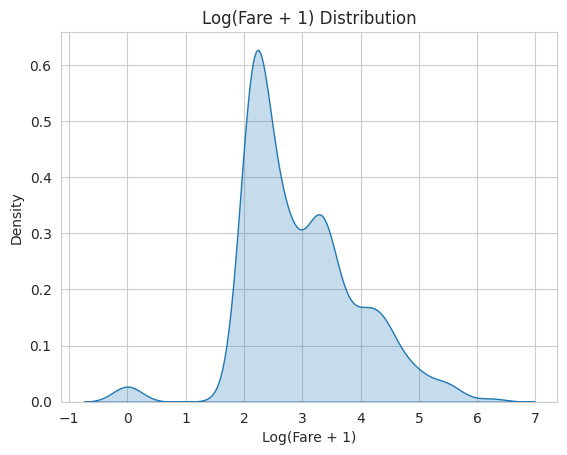

In [27]:
# Log-transformed fare
sns.kdeplot(np.log1p(df['Fare']), fill=True)
plt.title("Log(Fare + 1) Distribution")
plt.xlabel("Log(Fare + 1)")
plt.show()

Much better distribution after log transform.

## 4. Bivariate Analysis — Features vs Survival

### Pclass vs Survival

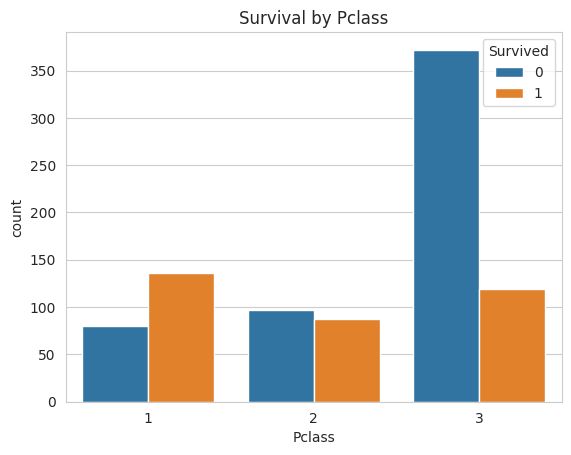

Survival rate by Pclass:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


In [28]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Pclass")
plt.show()

print("Survival rate by Pclass:")
print(df.groupby('Pclass')['Survived'].mean().round(3))

Clear class divide: 1st class ~63% survival vs 3rd class ~24%. Wealth and cabin location mattered.

### Sex vs Survival

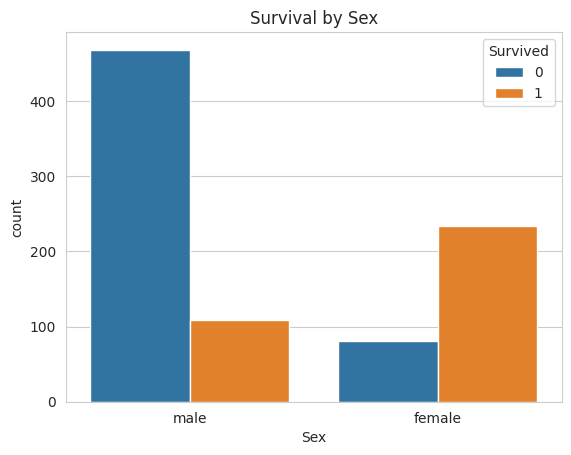

Survival rate by Sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


In [29]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Sex")
plt.show()

print("Survival rate by Sex:")
print(df.groupby('Sex')['Survived'].mean().round(3))

**"Women and children first"** — females had 74% survival vs 19% for males. This is the single strongest predictor.

### Age vs Survival

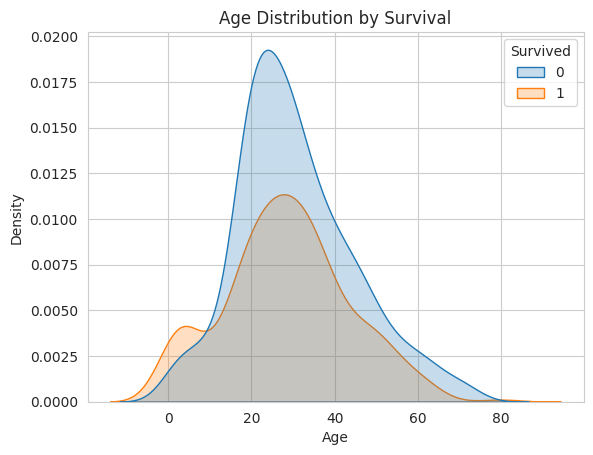

In [30]:
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True)
plt.title("Age Distribution by Survival")
plt.show()

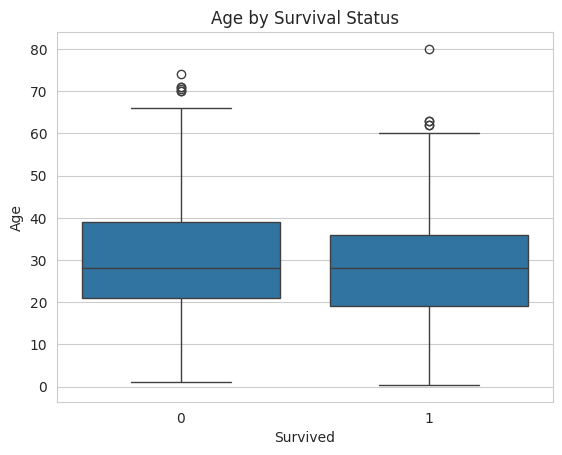

In [31]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age by Survival Status")
plt.show()

Ages are similar overall, but notice the spike around 0-5 years in survivors — young children had priority.

### Fare vs Survival

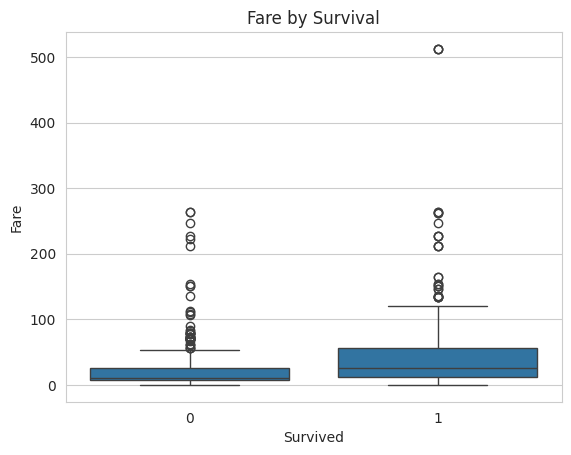

In [32]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare by Survival")
plt.show()

Survivors paid higher fares on average, but fare is heavily linked with Pclass — it's mostly a proxy for class.

### SibSp & Parch vs Survival

Survival rate by SibSp:
SibSp
0    0.345
1    0.536
2    0.464
3    0.250
4    0.167
5    0.000
8    0.000
Name: Survived, dtype: float64


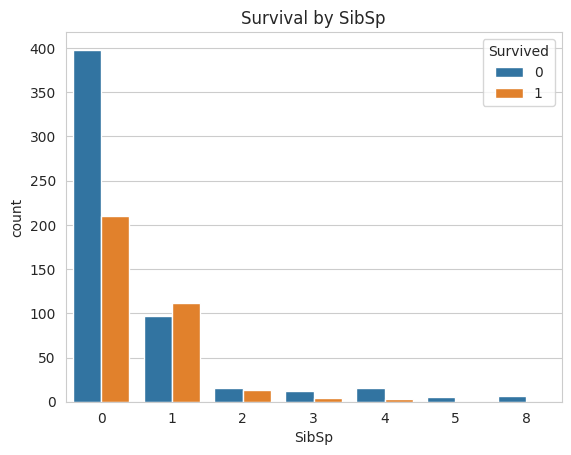

Survival rate by Parch:
Parch
0    0.344
1    0.551
2    0.500
3    0.600
4    0.000
5    0.200
6    0.000
Name: Survived, dtype: float64


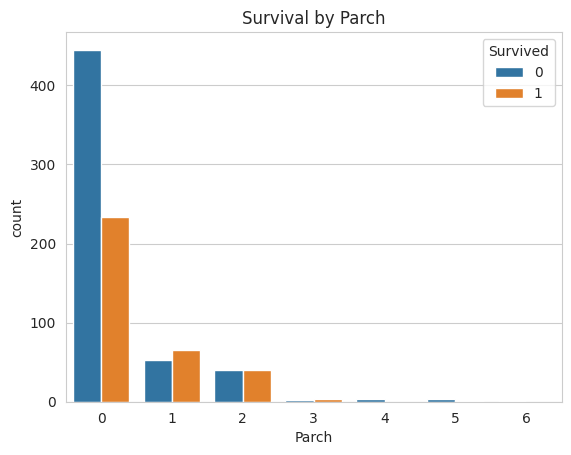

In [33]:
for col in ['SibSp', 'Parch']:
    print(f"Survival rate by {col}:")
    print(df.groupby(col)['Survived'].mean().round(3))
    sns.countplot(x=col, hue='Survived', data=df)
    plt.title(f"Survival by {col}")
    plt.show()

Both show a **sweet spot** — passengers with 1-2 family members survived more than solo travelers or large families. Suggests a FamilySize feature would be useful.

### Embarked vs Survival

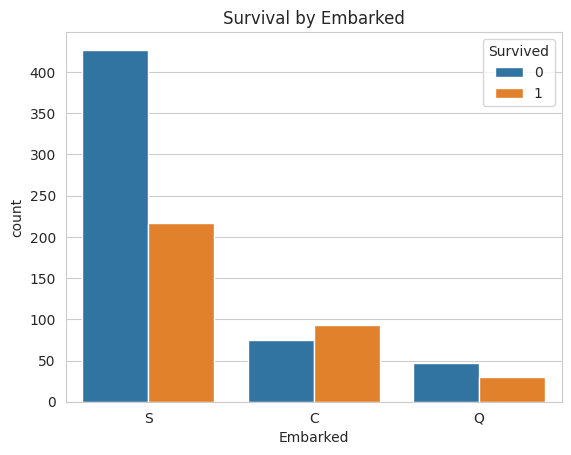

Survival rate by Embarked:
Embarked
C    0.554
Q    0.390
S    0.337
Name: Survived, dtype: float64


In [34]:
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title("Survival by Embarked")
plt.show()

print("Survival rate by Embarked:")
print(df.groupby('Embarked')['Survived'].mean().round(3))

Cherbourg (C) has the highest survival rate (~55%). But is this a real effect, or just because more 1st class passengers boarded there?

## 5. Multivariate Analysis

### Embarked × Pclass — Is Embarked Just a Proxy?

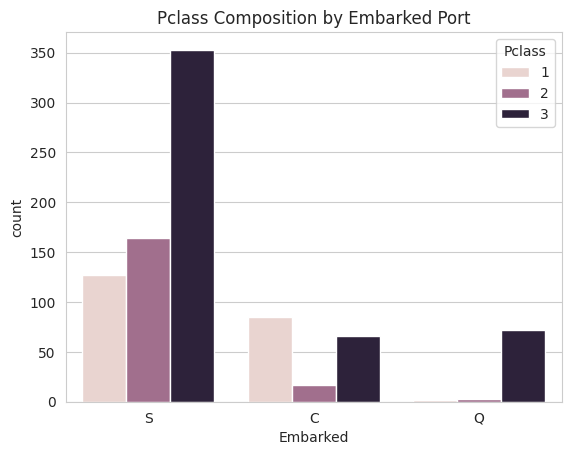

In [35]:
sns.countplot(x='Embarked', hue='Pclass', data=df)
plt.title("Pclass Composition by Embarked Port")
plt.show()

Cherbourg's higher survival is mostly because ~50% of its passengers are 1st class, vs ~20% for Southampton. Embarked is largely a proxy for class composition.

### Correlation Heatmap

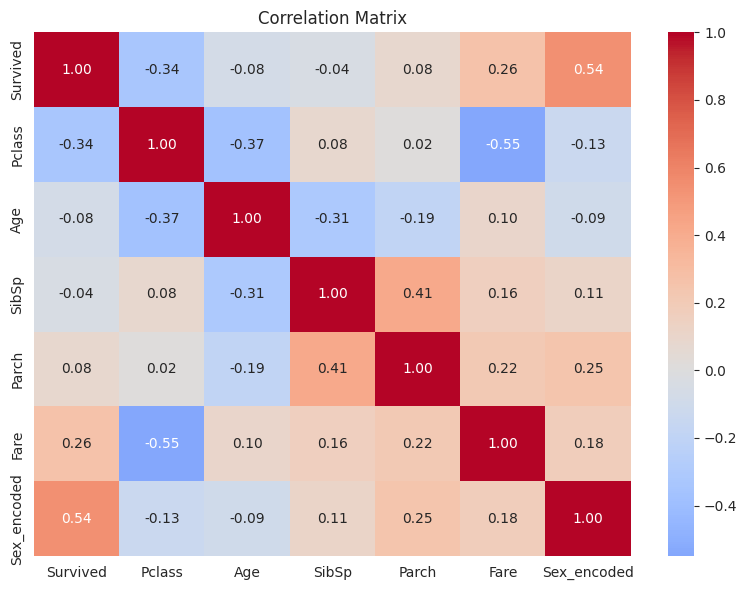

In [36]:
# Encode Sex temporarily for correlation
df_corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
df_corr['Sex_encoded'] = df['Sex'].map({'male': 0, 'female': 1})

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Strongest correlations with Survived:
1. **Sex** (+0.54)
2. **Pclass** (-0.34)
3. **Fare** (+0.26)

SibSp and Parch correlate with each other (0.41) — multicollinearity. Combining into FamilySize helps.

## 6. Deep Dives

### 6.1 Title Extraction from Name

Title encodes gender + age + social status. It's better than Sex alone because it separates boys (Master) from men (Mr).

In [37]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
print(df['Title'].value_counts())

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [38]:
# Group rare titles
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
    'Capt': 'Rare', 'Sir': 'Rare'
}
df['Title_grouped'] = df['Title'].map(title_map)

print("Survival rate by Title:")
print(df.groupby('Title_grouped')['Survived'].agg(['mean', 'count']).sort_values('mean', ascending=False))

Survival rate by Title:
                   mean  count
Title_grouped                 
Mrs            0.793651    126
Miss           0.702703    185
Master         0.575000     40
Rare           0.347826     23
Mr             0.156673    517


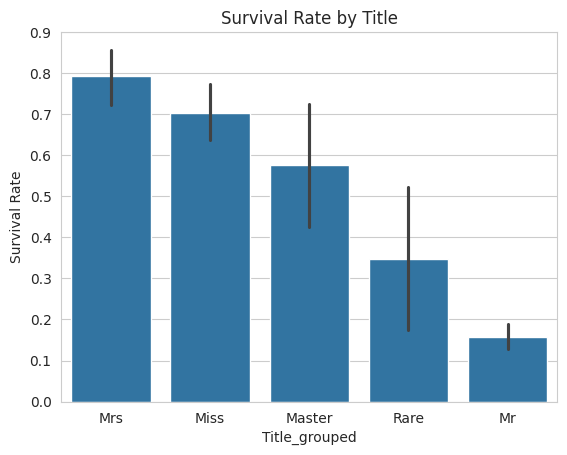

In [39]:
sns.barplot(x='Title_grouped', y='Survived', data=df, order=['Mrs', 'Miss', 'Master', 'Rare', 'Mr'])
plt.title("Survival Rate by Title")
plt.ylabel("Survival Rate")
plt.show()

Title is **extremely powerful**:
- **Mrs/Miss**: ~70-79% — women
- **Master**: ~58% — boys (median age ~4)
- **Mr**: ~16% — adult men

### 6.2 Family Size

In [40]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print("Survival rate by FamilySize:")
print(df.groupby('FamilySize')['Survived'].agg(['mean', 'count']))

Survival rate by FamilySize:
                mean  count
FamilySize                 
1           0.303538    537
2           0.552795    161
3           0.578431    102
4           0.724138     29
5           0.200000     15
6           0.136364     22
7           0.333333     12
8           0.000000      6
11          0.000000      7


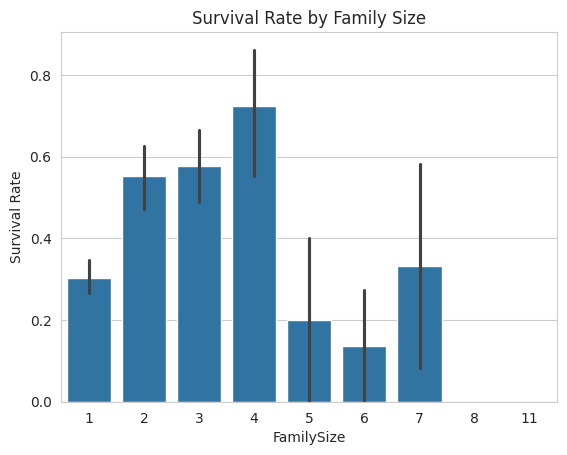

In [41]:
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Rate")
plt.show()

Clear **sweet spot**:
- Solo travelers (1): ~30% — no one to coordinate with
- Small families (2-4): ~50%+ — best outcomes
- Large families (5+): ~16% — hard to evacuate as a group, mostly 3rd class

### 6.3 Age Groups

In [42]:
bins = [0, 12, 18, 35, 55, 80]
labels = ['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print("Survival rate by AgeGroup:")
print(df.groupby('AgeGroup', observed=True)['Survived'].agg(['mean', 'count']))

Survival rate by AgeGroup:
                 mean  count
AgeGroup                    
Child        0.579710     69
Teen         0.428571     70
Adult        0.382682    358
Middle-aged  0.401130    177
Senior       0.300000     40


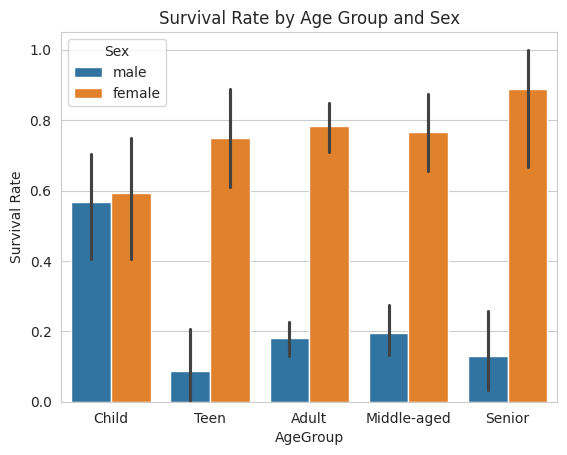

In [43]:
sns.barplot(x='AgeGroup', y='Survived', hue='Sex', data=df, order=labels)
plt.title("Survival Rate by Age Group and Sex")
plt.ylabel("Survival Rate")
plt.show()

- Children have the highest survival (~54%)
- Females dominate survival across all age groups
- Male children still have decent survival (~40%+), male teens/adults plummet to ~15-20%

### 6.4 Cabin Analysis

In [44]:
df['HasCabin'] = df['Cabin'].notna().astype(int)

df['HasCabin'].value_counts()

HasCabin
0    687
1    204
Name: count, dtype: int64

Survival rate — Has Cabin vs No Cabin:
HasCabin
0    0.300
1    0.667
Name: Survived, dtype: float64


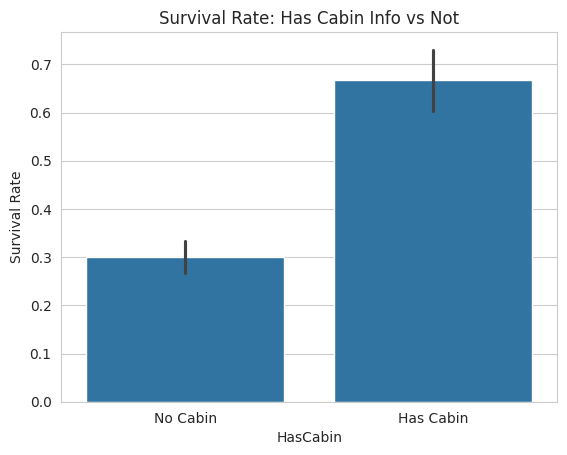

In [45]:

print("Survival rate — Has Cabin vs No Cabin:")
print(df.groupby('HasCabin')['Survived'].mean().round(3))

sns.barplot(x='HasCabin', y='Survived', data=df)
plt.title("Survival Rate: Has Cabin Info vs Not")
plt.xticks([0, 1], ['No Cabin', 'Has Cabin'])
plt.ylabel("Survival Rate")
plt.show()

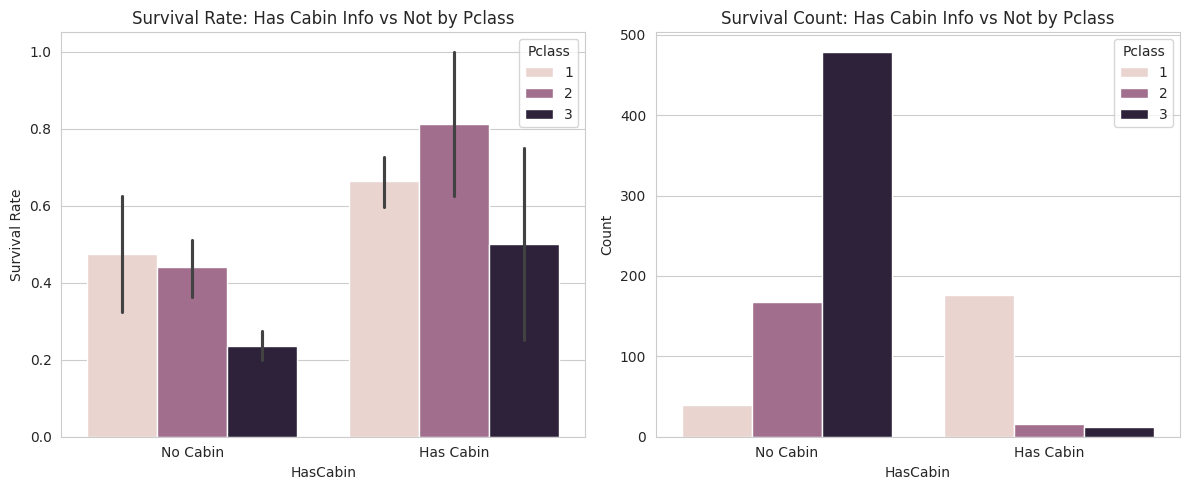

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x='HasCabin', y='Survived', hue='Pclass', data=df, ax=axes[0])
axes[0].set_title("Survival Rate: Has Cabin Info vs Not by Pclass")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Cabin', 'Has Cabin'])
axes[0].set_ylabel("Survival Rate")

sns.countplot(x='HasCabin', hue='Pclass', data=df, ax=axes[1])
axes[1].set_title("Survival Count: Has Cabin Info vs Not by Pclass")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Cabin', 'Has Cabin'])
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

<Axes: xlabel='HasCabin', ylabel='count'>

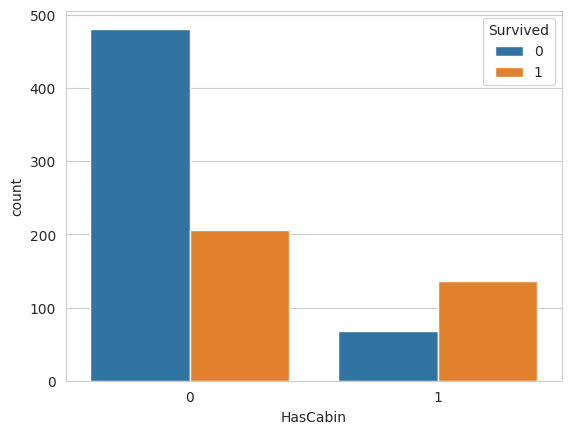

In [47]:
sns.countplot(x='HasCabin', hue='Survived', data=df)


```py
HasCabin
0    687
1    204
```

#### Survivial rate
- Having cabin -> 67%
- No cabin -> 30%

Having cabin definitely helps in survival.

Another observation is that most of the passengers with cabins are from 1st class, also survival rate in general is higher irrespective of class if the passenger has a cabin. This is a strong indicator that having a cabin is a strong predictor of survival

## 7. Key Findings & Recommendations

### Findings (ranked by importance)

1. **Sex** is the strongest predictor — 74% female vs 19% male survival
2. **Pclass** is second — 63% (1st) vs 24% (3rd)
3. **Title** (from Name) captures gender + age + socialstatus — Master (~58%) vs Mr (~16%) is very useful
4. **Family size** Small families (2-4) survive most
5. **Age** matters for children but is weak for adults
6. **Fare** is largely a Pclass proxy —> log-transform for modeling
7. **Embarked** is mostly a proxy for class 
8. **HasCabin** is a useful binary feature (proxy for 1st class)
    - Better suited for tree-based models than linear ones (due to high correlation with Pclass)
    - Also models like XGBoost can handle missing values, so we can keep it as is without imputation

### Recommended Features for Modeling

| Feature | Source |
|---------|--------|
| Pclass | Direct | 
| Sex | Direct | 
| Age | Imputed by Pclass+Sex | 
| Title_grouped | From Name | 
| FamilySize | SibSp + Parch + 1 | 
| log(Fare) | Log-transformed | 
| HasCabin | Cabin not null | 
| Embarked | Imputed mode | 

### Preprocessing Notes
- **Age**: Impute with median by Pclass + Sex (not global median)
- **Embarked**: Impute 2 missing rows with mode
- **Fare**: 1 missing in test set — impute by Pclass median
- **Drop**: PassengerId, Name (after extracting Title), Ticket, Cabin (after extracting HasCabin)
